# what can we tune in SVM

step-1

SVM finds a hyperplane that best separates classes. The tuning controls: how much you penalize misclassifications (C), the shape of the boundary (kernel), and the curve tightness (gamma).

In [ ]:
# SVM Hyperparameters:
# C       — how hard to fit. High C = fit harder, risk overfit
# kernel  — shape of decision boundary
# gamma   — only for rbf/poly. Controls how curved the boundary is

# Mental model:
# C=0.1  → allow many misclassifications, simple/wide boundary
# C=100  → allow almost none, complex/tight boundary

# gamma='scale' → 1/(n_features * X.var())   ← default, usually good
# gamma='auto'  → 1/n_features
# gamma=0.001   → low: smoother boundary (safer)
# gamma=10      → high: very curved, fits individual points (overfit risk)

In [ ]:
kernel='linear':
            Straight line/plane boundary. Fast. Best for text classification or linearly separable data
kernel='rbf':
            Gaussian. Curved boundary. Best for most non-linear problems. Default choice.
kernel='poly':
            Polynomial. More complex. Rarely needed, use rbf first
C (low):
            Soft margin — allows more misclassifications for a smoother boundary
C (high):
            Hard margin — tries to classify everything correctly, tighter boundary

SVM is slow on large datasets (>50k rows). Use LinearSVC for large data — it's much faster for linear kernel.

Step 2 — prepare data

SVM is extremely sensitive to feature scale. Scaling is not optional here — unscaled data gives very poor results.

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform
import numpy as np

X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [ ]:
loguniform:
        scipy distribution for sampling C/gamma on log scale in RandomizedSearch
load_wine:
        178 samples, 13 features, 3 wine classes. Good for multi-class SVM practice

Use RandomizedSearchCV for SVM. Grid of C x gamma can be huge. Random sampling finds good results faster

# Step 3 — RandomizedSearchCV

For SVM, random search over C and gamma is more efficient than grid search. We sample from continuous distributions using scipy.stats.

In [2]:
param_dist = {
    'C':      loguniform(0.1, 1000),   # samples randomly from 0.1 to 1000
    'gamma':  loguniform(1e-4, 1),    # samples randomly from 0.0001 to 1
    'kernel': ['rbf', 'linear']
}

model = SVC(probability=True, random_state=42)

rand_search = RandomizedSearchCV(
    model, param_dist,
    n_iter=30,          # try 30 random combos
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)

print(rand_search.best_params_)
print("Best CV score:", round(rand_search.best_score_, 4))

{'C': 0.6788387912421219, 'gamma': 0.018655260217376828, 'kernel': 'rbf'}
Best CV score: 0.9931


In [ ]:
loguniform(0.1, 1000)
            Samples C values randomly from log-uniform distribution. Better than fixed list for continuous 
            params
n_iter=30
                How many random combos to try. More = better chance of finding optimum, but slower
probability=True
                Needed to use predict_proba() later. Adds slight overhead during training

When kernel='linear' is selected, gamma is ignored. RandomizedSearch handles this — it just tries both.

Step 4 — evaluate

After finding best params, evaluate on test set and optionally retrain with best params on full train data.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



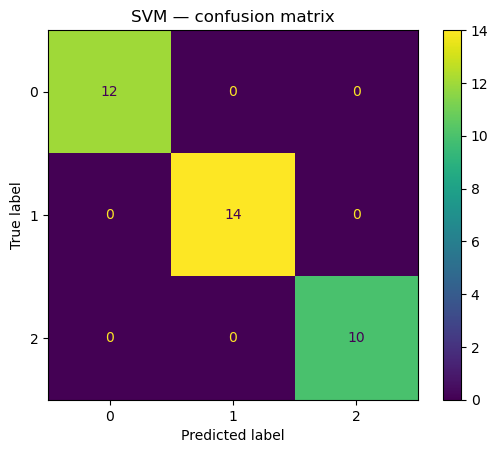

Final test accuracy: 1.0


In [3]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_svm = rand_search.best_estimator_
y_pred = best_svm.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test)
plt.title("SVM — confusion matrix")
plt.show()

# Optional: retrain best params on ALL train data
final_svm = SVC(**rand_search.best_params_, probability=True)
final_svm.fit(X_train, y_train)
print("Final test accuracy:", final_svm.score(X_test, y_test))

In [ ]:
best_estimator_
            Already fitted with best params on train data. Use directly.
SVC(**best_params_)
        ** unpacks the dict as keyword args. Equivalent to typing each param manually
ConfusionMatrixDisplay
        sklearn's built-in confusion matrix visualizer — no manual plotting needed

SVM test accuracy is often the same as CV score. If test score >> CV score, you might have data leakage. If test << CV, check for distribution shift.